In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import math

from common import (
    INDEX_ORDER,
    index_colors,
    index_markers,
    transform_duckdb_index_name,
    transform_pgvector_index_name,
    apply_style,
    PLOT_DPI,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    TITLE_FONTSIZE,
    MARKER_SIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
)


def compute_qps(metrics: dict) -> float:
    """Compute QPS from serial_latencies (seconds)."""
    latencies = metrics.get("serial_latencies")
    if not latencies:
        raise ValueError("serial_latencies is missing or empty in metrics")
    return 1.0 / np.median(latencies)


def get_arxiv_dataset_order(entry: dict) -> str:
    """Return the dataset order variant for an ArxivFilter result entry.

    Supports both the new 'arxiv_dataset_order' field and the legacy
    'sorted_by_update_date' boolean for backward compatibility.
    """
    custom = entry["task_config"]["case_config"].get("custom_case", {})
    # New-style: explicit string field
    order = custom.get("arxiv_dataset_order")
    if order is not None:
        return order
    # Legacy: boolean sorted_by_update_date
    if custom.get("sorted_by_update_date", False):
        return "sorted_by_update_date"
    return "original"


def lighten(color, amount=0.45):
    """Mix *color* toward white by *amount* (0 = unchanged, 1 = white)."""
    r, g, b, a = mcolors.to_rgba(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount, a)


# ---------------------------------------------------------------------------
# Dataset order definitions for comparison plots.
# Each entry: (key in records_by_order, legend suffix, linestyle, lighten_amount, zorder_base)
# Toggle entries on/off by commenting them out.
# ---------------------------------------------------------------------------
DATASET_ORDERS = [
    # ("original",              "original",  "--", 0.25, 5),
    ("randomly_shuffled",     "random",    ":",  0.55, 1),
    ("sorted_by_update_date", "sorted",    "-",  0.00, 9),
]


FILTER_TYPE_TITLES = {
    "EM": "Exact Match (EM)\n$\\mathit{int\\_col = 3}$",
    "R": "Range (R)\n$\\mathit{int\\_col\\ BETWEEN\\ start\\ AND\\ end}$",
    "EMIS": "Exact Match In Set (EMIS)\n$\\mathit{list\\_contains(string\\_list\\_col,\\ 'abc')}$",
}

FILTER_TYPE_ORDER = ["EM", "R", "EMIS"]

# Thread count used for cells 2-3 (overview and dataset-order comparison plots).
# The last cell (selectivity buckets) shows both thread counts side-by-side.
MAIN_THREADS = 14

# ---------------------------------------------------------------------------
# 1. Load all result JSONs from the index_filtered_search results directory
#    ** BLOB INTERFACE ONLY **
# ---------------------------------------------------------------------------
# records_by_order: "original" | "sorted_by_update_date" | "randomly_shuffled" → list of records
records_by_order: dict[str, list[dict]] = {
    "original": [],
    "sorted_by_update_date": [],
    "randomly_shuffled": [],
}

# all_records_with_threads: same but keeps all thread counts (for the last cell)
all_records_with_threads: list[dict] = []

# Legacy aliases kept for backward compatibility with later cells
records = records_by_order["original"]
records_sorted = records_by_order["sorted_by_update_date"]

# Load DuckDB results
duckdb_results_dir = pathlib.Path("../experiments/results/index_filtered_search_arxiv/DuckDB")
duckdb_json_files = sorted(duckdb_results_dir.glob("*.json"))

for path in duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_cfg = task_cfg["db_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        # Only include blob-interface results
        if not db_case_cfg.get("use_blob_interface", False):
            continue

        custom = case_cfg.get("custom_case", {})
        filter_type = custom.get("arxiv_filter_type")
        if filter_type is None:
            continue

        db_label = json.loads(db_cfg.get("db_label", "{}"))
        global_version = db_label.get("global_version", None)

        index_name = transform_duckdb_index_name(db_case_cfg, global_version)
        threads = db_cfg.get("duckdb_threads")

        order = get_arxiv_dataset_order(entry)

        record = {
            "recall": metrics["recall"],
            "serial_qps": compute_qps(metrics),
            "index": index_name,
            "filter_type": filter_type,
            "db_type": "DuckDB",
            "threads": threads,
        }

        # Keep all records (any thread count) for the last cell
        all_records_with_threads.append({**record, "order": order})

        # Only add to records_by_order if threads match MAIN_THREADS
        if threads == MAIN_THREADS and order in records_by_order:
            records_by_order[order].append(record)

# Load pgvector results (if available)
pgvector_results_dir = pathlib.Path("../experiments/results/index_filtered_search_arxiv/pgvector")
pgvector_json_files = sorted(pgvector_results_dir.glob("*.json")) if pgvector_results_dir.exists() else []

for order_name, recs in records_by_order.items():
    if recs:
        print(f"Loaded {len(recs):>4d} {order_name} results (threads={MAIN_THREADS})")
print(f"Loaded {len(all_records_with_threads):>4d} total blob results (all thread counts)")
print(f"  from {len(duckdb_json_files)} DuckDB files and {len(pgvector_json_files)} pgvector files")
print("  (blob interface only)")
records[:3]

Loaded   30 sorted_by_update_date results (threads=14)
Loaded   30 randomly_shuffled results (threads=14)
Loaded  120 total blob results (all thread counts)
  from 320 DuckDB files and 69 pgvector files
  (blob interface only)


[]

In [2]:
# ---------------------------------------------------------------------------
# 2. Determine filter types present in data
# ---------------------------------------------------------------------------
all_records = [r for recs in records_by_order.values() for r in recs]
filter_types = [ft for ft in FILTER_TYPE_ORDER if any(r["filter_type"] == ft for r in all_records)]
print(f"Filter types: {filter_types}")

Filter types: ['R']


In [3]:
# ---------------------------------------------------------------------------
# 3. Scatter plot: Recall vs QPS, one subplot per filter type
# ---------------------------------------------------------------------------
from collections import defaultdict
from matplotlib.lines import Line2D

apply_style()

# Group records: filter_type → index_type → list of (recall, qps) tuples
grouped: dict[str, dict[str, list[tuple[float, float]]]] = defaultdict(lambda: defaultdict(list))

for r in records:
    grouped[r["filter_type"]][r["index"]].append((r["recall"], r["serial_qps"]))

# Get all unique index types present in the data, in canonical order
all_index_types = set()
for ft in filter_types:
    all_index_types.update(grouped[ft].keys())
all_index_types = [idx for idx in INDEX_ORDER if idx in all_index_types]

shared_ylim = None

if not filter_types or not records:
    print("No original-order results found — skipping overview plot.")
else:
    # Create subplots: one per filter type (1 row, 3 cols)
    n_plots = len(filter_types)
    fig, axes = plt.subplots(1, n_plots, figsize=(5.0 * n_plots, 5.0), squeeze=False, sharey=True)

    for ft_idx, ft in enumerate(filter_types):
        ax = axes[0][ft_idx]

        for index_type in all_index_types:
            points = grouped[ft].get(index_type, [])
            if not points:
                continue

            points.sort(key=lambda p: p[0])
            recalls = [p[0] for p in points]
            qps_vals = [p[1] for p in points]

            color = index_colors.get(index_type, "#808080")
            marker = index_markers.get(index_type, "o")
            z_scatter = 10 if index_type == "DuckDB" else 3
            z_line = 9 if index_type == "DuckDB" else 2

            ax.scatter(recalls, qps_vals, label=index_type, color=color,
                       marker=marker, s=MARKER_SIZE, zorder=z_scatter, edgecolors='white', linewidths=0.5)
            ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6, zorder=z_line)

        title = FILTER_TYPE_TITLES.get(ft, ft)
        ax.set_title(title, fontsize=TITLE_FONTSIZE, color=FONT_COLOR)
        ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)
        if ft_idx == 0:
            ax.set_ylabel("Throughput (QPS)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

        ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
        ax.set_axisbelow(True)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        ax.set_xlim(-0.05, 1.05)
        ax.set_xticks([i / 5 for i in range(6)])
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))

        ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
        ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
        ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

    # Shared legend across all subplots
    legend_handles = []
    for index_type in all_index_types:
        color = index_colors.get(index_type, "#808080")
        marker = index_markers.get(index_type, "o")
        legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle='-',
                                      markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                      linewidth=1.2, alpha=0.8, label=index_type))

    fig.legend(handles=legend_handles, loc="upper center", ncol=math.ceil(len(all_index_types) / 2),
               frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.12))

    fig.tight_layout(rect=[0, 0, 1, 0.92])
    fig.subplots_adjust(wspace=0.15)
    plt.savefig("index_filtered_search_arxiv_blob.pdf", dpi=PLOT_DPI, bbox_inches='tight')

    shared_ylim = axes[0][0].get_ylim()

No original-order results found — skipping overview plot.


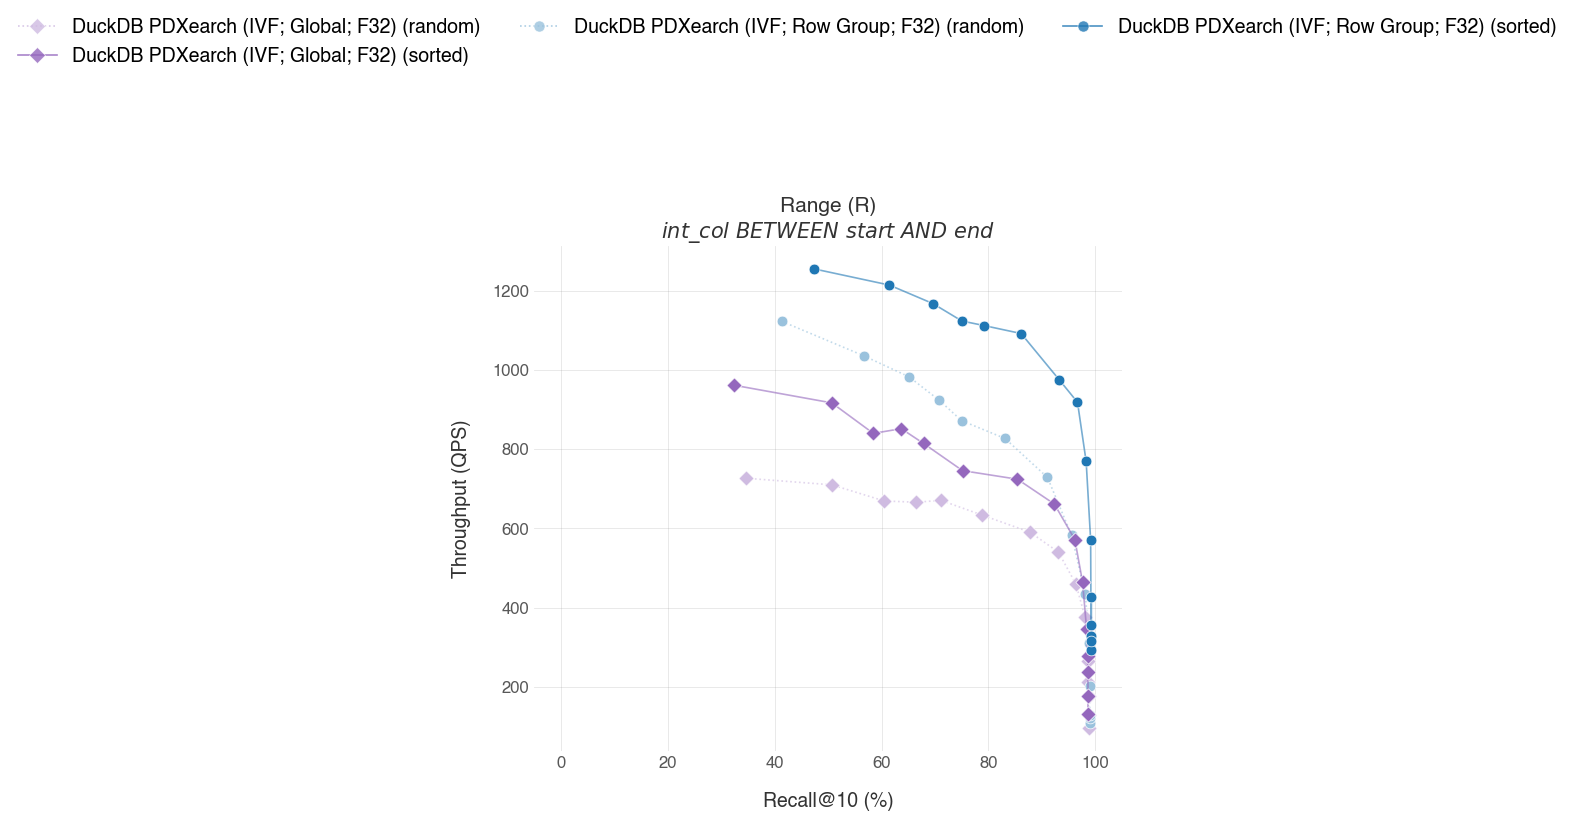

In [4]:
# ---------------------------------------------------------------------------
# 4. Scatter plot: Range (R) — original vs randomly shuffled vs sorted by update_date
# ---------------------------------------------------------------------------
from collections import defaultdict
from matplotlib.lines import Line2D

apply_style()

# Group Range (R) records per dataset order
grouped_by_order: dict[str, dict[str, list[tuple[float, float]]]] = {}
for order_key, _, _, _, _ in DATASET_ORDERS:
    grouped: dict[str, list[tuple[float, float]]] = defaultdict(list)
    for r in records_by_order.get(order_key, []):
        if r["filter_type"] == "R":
            grouped[r["index"]].append((r["recall"], r["serial_qps"]))
    grouped_by_order[order_key] = grouped

# All index types across all dataset orders, in canonical order
all_idx = set()
for g in grouped_by_order.values():
    all_idx.update(g.keys())
all_idx = [idx for idx in INDEX_ORDER if idx in all_idx]

fig, ax = plt.subplots(1, 1, figsize=(7.0, 7.0))

# Plot each dataset order variant
for order_key, _, linestyle, lighten_amount, z_base in DATASET_ORDERS:
    grouped = grouped_by_order[order_key]
    for index_type in all_idx:
        points = grouped.get(index_type, [])
        if not points:
            continue
        points.sort(key=lambda p: p[0])
        recalls = [p[0] for p in points]
        qps_vals = [p[1] for p in points]

        base_color = index_colors.get(index_type, "#808080")
        color = lighten(base_color, lighten_amount)
        marker = index_markers.get(index_type, "o")

        ax.scatter(recalls, qps_vals, color=color, marker=marker, s=MARKER_SIZE,
                   zorder=z_base + 1, edgecolors='white', linewidths=0.5)
        ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6,
                linestyle=linestyle, zorder=z_base)

title = FILTER_TYPE_TITLES["R"]
ax.set_title(title, fontsize=TITLE_FONTSIZE, color=FONT_COLOR)
ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)
ax.set_ylabel("Throughput (QPS)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(shared_ylim)
ax.set_xticks([i / 5 for i in range(6)])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))

ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

# Legend: one entry per (index_type, dataset_order) combination
legend_handles = []
for index_type in all_idx:
    base_color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    for order_key, label_suffix, linestyle, lighten_amount, _ in DATASET_ORDERS:
        # Only add legend entry if this combination has data
        if not grouped_by_order[order_key].get(index_type):
            continue
        color = lighten(base_color, lighten_amount)
        legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle=linestyle,
                                      markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                      linewidth=1.2, alpha=0.8, label=f"{index_type} ({label_suffix})"))

fig.legend(handles=legend_handles, loc="upper center", ncol=min(3, len(legend_handles)),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.18))

fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("index_filtered_search_arxiv_sorted_by_update_date_blob.pdf", dpi=PLOT_DPI, bbox_inches='tight')

Selectivity buckets (4):
  B0: 0%–5%  (15 queries, actual range 0.65%–4.90%)
  B1: 5%–25%  (222 queries, actual range 5.01%–24.86%)
  B2: 25%–75%  (673 queries, actual range 25.05%–74.92%)
  B3: 75%–100%  (90 queries, actual range 75.05%–93.45%)


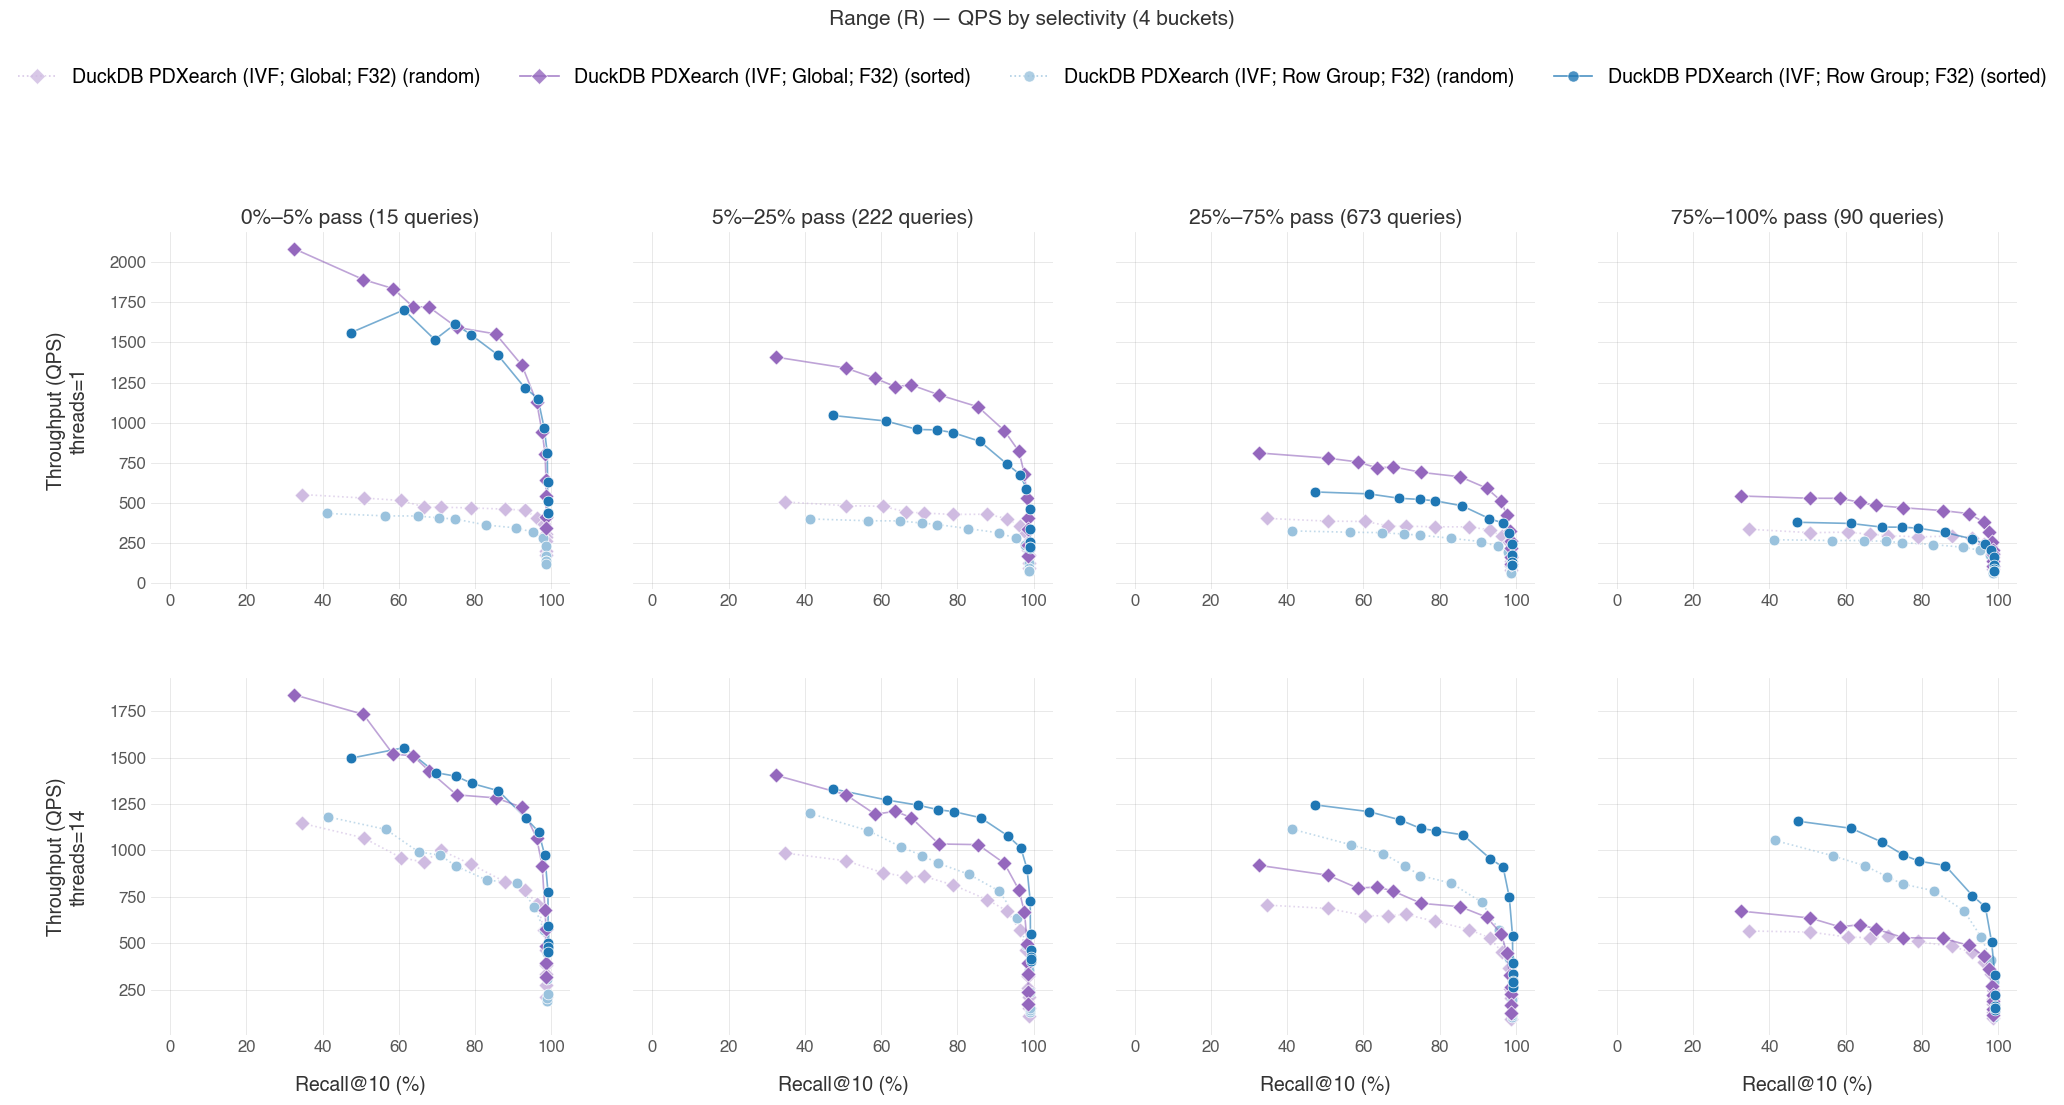

In [5]:
# ---------------------------------------------------------------------------
# 5. Range (R) QPS by selectivity bucket — all dataset orders
#    Two rows: threads=1 (top) and threads=14 (bottom)
# ---------------------------------------------------------------------------
from collections import defaultdict
from matplotlib.lines import Line2D

apply_style()

# Explicit selectivity buckets: (min_selectivity, max_selectivity)
# Queries whose selectivity falls in [min, max] are included in that bucket.
SELECTIVITY_BUCKETS = [
    (0.00, 0.05),   # 0%–5% pass
    (0.05, 0.25),   # 5%–25% pass
    (0.25, 0.75),   # 25%–75% pass
    (0.75, 1.00),   # 75%–100% pass
]
NUM_BUCKETS = len(SELECTIVITY_BUCKETS)
THREAD_COUNTS = [1, 14]  # One row per thread count

# Load per-query selectivities from the precomputed JSON
with open("arxiv_range_selectivity.json") as f:
    sel_data = json.load(f)

# Selectivities for the first max_search_queries (1000) test queries
MAX_QUERIES = 1000
query_selectivities = np.array([q["selectivity"] for q in sel_data["queries"][:MAX_QUERIES]])

# Assign each query to a bucket based on its selectivity value
bucket_assignment = np.full(MAX_QUERIES, -1, dtype=int)
for b, (smin, smax) in enumerate(SELECTIVITY_BUCKETS):
    mask = (query_selectivities >= smin) & (query_selectivities <= smax)
    bucket_assignment[mask] = b

# Print bucket stats
print(f"Selectivity buckets ({NUM_BUCKETS}):")
for b, (smin, smax) in enumerate(SELECTIVITY_BUCKETS):
    count = (bucket_assignment == b).sum()
    actual_sels = query_selectivities[bucket_assignment == b]
    if len(actual_sels) > 0:
        print(f"  B{b}: {smin:.0%}–{smax:.0%}  ({count} queries, actual range {actual_sels.min():.2%}–{actual_sels.max():.2%})")
    else:
        print(f"  B{b}: {smin:.0%}–{smax:.0%}  ({count} queries)")
unassigned = (bucket_assignment == -1).sum()
if unassigned > 0:
    print(f"  {unassigned} queries not assigned to any bucket")

# ---------------------------------------------------------------------------
# Re-process raw result JSONs to extract per-query latencies for Range (R)
# ---------------------------------------------------------------------------
def compute_bucket_qps(latencies: list[float], bucket_assignment: np.ndarray, num_buckets: int) -> list[float]:
    """Given per-query latencies and bucket assignments, return QPS per bucket."""
    lats = np.array(latencies)
    qps_per_bucket = []
    for b in range(num_buckets):
        mask = bucket_assignment == b
        bucket_lats = lats[mask]
        if len(bucket_lats) == 0:
            qps_per_bucket.append(0.0)
        else:
            qps_per_bucket.append(1.0 / np.median(bucket_lats))
    return qps_per_bucket


# Records per bucket per (threads, dataset_order):
#   (threads, order_key) → list[bucket_idx → dict[index_name → list[(recall, qps)]]]
bucket_records: dict[tuple[int, str], list[dict[str, list[tuple[float, float]]]]] = {}
active_order_keys = {key for key, _, _, _, _ in DATASET_ORDERS}
for tc in THREAD_COUNTS:
    for order_key in active_order_keys:
        bucket_records[(tc, order_key)] = [defaultdict(list) for _ in range(NUM_BUCKETS)]

for path in duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_cfg = task_cfg["db_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        # Only include blob-interface results
        if not db_case_cfg.get("use_blob_interface", False):
            continue

        custom = case_cfg.get("custom_case", {})
        filter_type = custom.get("arxiv_filter_type")
        if filter_type != "R":
            continue

        latencies = metrics.get("serial_latencies", [])
        if len(latencies) != MAX_QUERIES:
            continue

        threads = db_cfg.get("duckdb_threads")
        if threads not in THREAD_COUNTS:
            continue

        order = get_arxiv_dataset_order(entry)
        if order not in active_order_keys:
            continue

        db_label = json.loads(db_cfg.get("db_label", "{}"))
        global_version = db_label.get("global_version", None)
        index_name = transform_duckdb_index_name(db_case_cfg, global_version)
        recall = metrics["recall"]

        qps_list = compute_bucket_qps(latencies, bucket_assignment, NUM_BUCKETS)
        for b in range(NUM_BUCKETS):
            bucket_records[(threads, order)][b][index_name].append((recall, qps_list[b]))

# ---------------------------------------------------------------------------
# Plot: NUM_BUCKETS columns x len(THREAD_COUNTS) rows
# ---------------------------------------------------------------------------
all_idx_q = set()
for key in bucket_records:
    for b in range(NUM_BUCKETS):
        all_idx_q.update(bucket_records[key][b].keys())
all_idx_q = [idx for idx in INDEX_ORDER if idx in all_idx_q]

n_rows = len(THREAD_COUNTS)
n_cols = NUM_BUCKETS
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.0 * n_cols, 5.0 * n_rows), squeeze=False, sharey="row")

for row_idx, tc in enumerate(THREAD_COUNTS):
    for b in range(NUM_BUCKETS):
        ax = axes[row_idx][b]
        smin, smax = SELECTIVITY_BUCKETS[b]

        for order_key, _, linestyle, lighten_amount, z_base in DATASET_ORDERS:
            bucket_data = bucket_records[(tc, order_key)][b]
            for index_type in all_idx_q:
                points = bucket_data.get(index_type, [])
                if not points:
                    continue
                points.sort(key=lambda p: p[0])
                recalls = [p[0] for p in points]
                qps_vals = [p[1] for p in points]
                color = lighten(index_colors.get(index_type, "#808080"), lighten_amount)
                marker = index_markers.get(index_type, "o")
                ax.scatter(recalls, qps_vals, color=color, marker=marker, s=MARKER_SIZE,
                           zorder=z_base + 1, edgecolors='white', linewidths=0.5)
                ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6,
                        linestyle=linestyle, zorder=z_base)

        # Top row: show selectivity range in title
        n_queries = (bucket_assignment == b).sum()
        if row_idx == 0:
            ax.set_title(f"{smin:.0%}–{smax:.0%} pass ({n_queries} queries)", fontsize=TITLE_FONTSIZE, color=FONT_COLOR)

        # Bottom row: x-axis label
        if row_idx == n_rows - 1:
            ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

        # Left column: y-axis label with thread count
        if b == 0:
            ax.set_ylabel(f"Throughput (QPS)\nthreads={tc}", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

        ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
        ax.set_axisbelow(True)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        ax.set_xlim(-0.05, 1.05)
        ax.set_xticks([i / 5 for i in range(6)])
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))
        ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
        ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
        ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

# Shared legend
legend_handles = []
for index_type in all_idx_q:
    base_color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    for order_key, label_suffix, linestyle, lighten_amount, _ in DATASET_ORDERS:
        has_data = any(
            bucket_records[(tc, order_key)][b].get(index_type)
            for tc in THREAD_COUNTS
            for b in range(NUM_BUCKETS)
        )
        if not has_data:
            continue
        color = lighten(base_color, lighten_amount)
        legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle=linestyle,
                                      markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                      linewidth=1.2, alpha=0.8, label=f"{index_type} ({label_suffix})"))

fig.legend(handles=legend_handles, loc="upper center", ncol=min(4, len(legend_handles)),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.06))

fig.suptitle(f"Range (R) — QPS by selectivity ({NUM_BUCKETS} buckets)", fontsize=TITLE_FONTSIZE, color=FONT_COLOR, y=1.10)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(wspace=0.15, hspace=0.25)
plt.savefig("index_filtered_search_arxiv_by_selectivity_blob.pdf", dpi=PLOT_DPI, bbox_inches='tight')